# Elitist Ant System (EAS) — TSPTW avec perturbations

**Problème** : Trouver une tournée optimale depuis le dépôt, visitant tous les clients **dans leurs fenêtres de temps** `[a, b]`, en minimisant le temps total de voyage.

**Perturbations** : Sur certains arcs `(i,j)`, pendant `[t_start, t_end]`, le temps de trajet est multiplié par `alpha`.

**EAS** : Variante de l'ACO où la **meilleure solution globale** dépose des phéromones à chaque itération en plus des fourmis ordinaires.

## 1. Imports & chargement des données

In [1]:
import json
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from copy import deepcopy
from dataclasses import dataclass, field
from typing import Optional

# ── Charger un dataset ──────────────────────────────────────────────────────
DATASET_DIR = Path("datasets")

available = sorted(DATASET_DIR.glob("*.json"))
print("Datasets disponibles :")
for p in available:
    print(" ", p)

DATASET_PATH = available[0]          # ← modifier si besoin
print(f"\nDataset chargé : {DATASET_PATH}")

with open(DATASET_PATH) as f:
    data = json.load(f)

Datasets disponibles :
  datasets\tsptwd_n10.json
  datasets\tsptwd_n100.json
  datasets\tsptwd_n1000.json
  datasets\tsptwd_n10000.json
  datasets\tsptwd_n200.json
  datasets\tsptwd_n300.json
  datasets\tsptwd_n50.json
  datasets\tsptwd_n500.json

Dataset chargé : datasets\tsptwd_n10.json


## 2. Modélisation du problème

In [2]:
@dataclass
class Node:
    id: int
    nom: str
    x: float
    y: float
    a: float          # fenêtre : ouverture
    b: Optional[float]  # fenêtre : fermeture (None = dépôt sans contrainte)
    service: float    # durée de service

@dataclass
class Perturbation:
    arc: tuple        # (i, j)
    t_start: float
    t_end: float
    alpha: float      # multiplicateur du temps de trajet

class TSPTW:
    """Instance du problème TSPTW avec perturbations."""

    def __init__(self, data: dict):
        self.scale    = data["meta"]["scale"]
        self.horizon  = data["meta"]["horizon"]

        depot_d = data["depot"]
        self.depot = Node(**depot_d)

        self.clients = [Node(**c) for c in data["clients"]]
        self.nodes   = [self.depot] + self.clients   # index 0 = dépôt
        self.n       = len(self.nodes)               # dépôt + n_clients

        self.perturbations = [
            Perturbation(arc=tuple(p["arc"]), t_start=p["t_start"],
                         t_end=p["t_end"],   alpha=p["alpha"])
            for p in data.get("perturbations", [])
        ]

        # Distance euclidienne mise à l'échelle
        self._dist = self._build_dist_matrix()

    # ── distances ────────────────────────────────────────────────────────────
    def _build_dist_matrix(self) -> np.ndarray:
        n = self.n
        D = np.zeros((n, n))
        for i, ni in enumerate(self.nodes):
            for j, nj in enumerate(self.nodes):
                D[i, j] = math.hypot(ni.x - nj.x, ni.y - nj.y) * self.scale
        return D

    def travel_time(self, i: int, j: int, t_depart: float) -> float:
        """Temps de trajet de i→j en partant à t_depart (perturbations incluses)."""
        base = self._dist[i, j]
        for p in self.perturbations:
            if tuple(p.arc) == (i, j) and p.t_start <= t_depart <= p.t_end:
                return base * p.alpha
        return base

    # ── évaluation d'une solution ─────────────────────────────────────────
    def evaluate(self, route: list[int]) -> tuple[float, bool]:
        """
        route : liste d'indices de noeuds (sans dépôt initial/final)
        Retourne (cout_total, faisable).
        """
        t = 0.0
        total_travel = 0.0
        prev = 0  # dépôt
        feasible = True

        for idx in route:
            tt = self.travel_time(prev, idx, t)
            t += tt
            total_travel += tt
            node = self.nodes[idx]
            if t < node.a:
                t = node.a   # attente autorisée
            if node.b is not None and t > node.b:
                feasible = False
            t += node.service
            prev = idx

        # retour au dépôt
        tt = self.travel_time(prev, 0, t)
        total_travel += tt
        return total_travel, feasible

    def n_clients(self):
        return len(self.clients)


problem = TSPTW(data)
print(f"Noeuds : {problem.n}  (dépôt + {problem.n_clients()} clients)")
print(f"Perturbations : {len(problem.perturbations)}")

Noeuds : 11  (dépôt + 10 clients)
Perturbations : 2


## 3. Elitist Ant System (EAS)

In [ ]:
class EAS:
    """
    Elitist Ant System pour TSPTW.

    Paramètres clés
    ---------------
    n_ants   : nombre de fourmis par itération
    n_iter   : nombre d'itérations
    alpha    : poids phéromone dans la sélection
    beta     : poids heuristique (1/distance)
    rho      : taux d'évaporation ∈ (0,1)
    e        : poids élitiste (combien de fois la best dépose ses phéromones)
    tau0     : phéromone initiale
    penalty  : pénalité pour solution infaisable
    """

    def __init__(self, problem: TSPTW,
                 n_ants: int   = 20,
                 n_iter: int   = 200,
                 alpha: float  = 1.0,
                 beta: float   = 2.0,
                 rho: float    = 0.1,
                 e: float      = 5.0,
                 tau0: float   = None,
                 penalty: float = 1e6,
                 seed: int     = None):

        self.pb      = problem
        self.n       = problem.n          # dépôt inclus
        self.n_ants  = n_ants
        self.n_iter  = n_iter
        self.alpha   = alpha
        self.beta    = beta
        self.rho     = rho
        self.e       = e
        self.penalty = penalty

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        # Heuristique η[i,j] = 1 / dist(i,j)
        dist = problem._dist
        with np.errstate(divide='ignore'):
            self.eta = np.where(dist > 0, 1.0 / dist, 0.0)

        # Phéromones initiales
        if tau0 is None:
            tau0 = 1.0 / (self.n * np.mean(dist[dist > 0]))
        self.tau = np.full((self.n, self.n), tau0)

        # Historique
        self.best_route  = None
        self.best_cost   = float('inf')
        self.best_feasible = False
        self.history_best = []
        self.history_avg  = []

    # ── construction d'une tournée par une fourmi ────────────────────────
    def _build_route(self) -> list[int]:
        """Construit une tournée (indices noeuds sans dépôt au début/fin)."""
        unvisited = list(range(1, self.n))  # indices clients
        route = []
        current = 0  # dépôt
        t = 0.0

        while unvisited:
            # Calcul des attractivités
            probs = []
            for j in unvisited:
                tau_ij = self.tau[current, j] ** self.alpha
                eta_ij = self.eta[current, j] ** self.beta
                probs.append(tau_ij * eta_ij)

            total = sum(probs)
            if total == 0:
                probs = [1.0 / len(unvisited)] * len(unvisited)
            else:
                probs = [p / total for p in probs]

            # Sélection par roulette
            chosen = random.choices(unvisited, weights=probs, k=1)[0]

            # Mise à jour du temps
            tt = self.pb.travel_time(current, chosen, t)
            t += tt
            node = self.pb.nodes[chosen]
            if t < node.a:
                t = node.a
            t += node.service

            route.append(chosen)
            unvisited.remove(chosen)
            current = chosen

        return route

    # ── coût pénalisé ─────────────────────────────────────────────────────
    def _penalized_cost(self, route: list[int]) -> float:
        cost, feasible = self.pb.evaluate(route)
        """if not feasible:
            cost += self.penalty"""
        return cost, feasible

    # ── mise à jour phéromones ────────────────────────────────────────────
    def _update_pheromones(self, all_routes: list, all_costs: list):
        # Évaporation
        self.tau *= (1.0 - self.rho)

        # Dépôt des fourmis ordinaires
        for route, cost in zip(all_routes, all_costs):
            delta = 1.0 / cost if cost > 0 else 0.0
            full  = [0] + route + [0]
            for i, j in zip(full[:-1], full[1:]):
                self.tau[i, j] += delta
                self.tau[j, i] += delta  # symétrique

        # Dépôt élitiste : la meilleure solution globale dépose e×Δτ*
        if self.best_route is not None:
            delta_star = self.e / self.best_cost if self.best_cost > 0 else 0.0
            full = [0] + self.best_route + [0]
            for i, j in zip(full[:-1], full[1:]):
                self.tau[i, j] += delta_star
                self.tau[j, i] += delta_star

    # ── boucle principale ─────────────────────────────────────────────────
    def run(self, verbose: bool = True) -> dict:
        for it in range(1, self.n_iter + 1):
            routes = [self._build_route() for _ in range(self.n_ants)]
            costs_feasibles = [self._penalized_cost(r) for r in routes]
            costs = [cf[0] for cf in costs_feasibles]

            # Meilleure fourmi de cette itération
            idx_best = int(np.argmin(costs))
            iter_best_cost, iter_best_feasible = costs_feasibles[idx_best]

            # Mise à jour meilleure globale
            if iter_best_cost < self.best_cost:
                self.best_cost     = iter_best_cost
                self.best_route    = routes[idx_best][:]
                self.best_feasible = iter_best_feasible

            self._update_pheromones(routes, costs)

            self.history_best.append(self.best_cost)
            self.history_avg.append(float(np.mean(costs)))

            if verbose and it % 20 == 0:
                feas = "✓" if self.best_feasible else "✗"
                print(f"  Iter {it:4d}/{self.n_iter}  "
                      f"best={self.best_cost:.1f} [{feas}]  "
                      f"avg={self.history_avg[-1]:.1f}")

        print("\n=== Résultat final ===")
        cost_real, feasible = self.pb.evaluate(self.best_route)
        print(f"  Coût réel  : {cost_real:.2f}")
        print(f"  Faisable   : {feasible}")
        print(f"  Route      : {[0] + self.best_route + [0]}")

        return {
            "route": self.best_route,
            "cost": cost_real,
            "feasible": feasible,
            "history_best": self.history_best,
            "history_avg":  self.history_avg,
        }

## 4. Lancement de l'algorithme

In [4]:
eas = EAS(
    problem = problem,
    n_ants  = 20,
    n_iter  = 200,
    alpha   = 1.0,   # importance phéromone
    beta    = 2.0,   # importance heuristique distance
    rho     = 0.1,   # taux d'évaporation
    e       = 5.0,   # poids élitiste
    penalty = 1e6,   # pénalité violation fenêtre
    seed    = data["meta"]["seed"],
)

result = eas.run(verbose=True)

  Iter   20/200  best=1000482.6 [✗]  avg=1000619.9
  Iter   40/200  best=1000478.7 [✗]  avg=1000600.4
  Iter   60/200  best=1000478.7 [✗]  avg=1000537.0
  Iter   80/200  best=1000478.7 [✗]  avg=1000545.4
  Iter  100/200  best=1000478.7 [✗]  avg=1000517.6
  Iter  120/200  best=1000478.7 [✗]  avg=1000500.2
  Iter  140/200  best=1000478.7 [✗]  avg=1000520.8
  Iter  160/200  best=1000478.7 [✗]  avg=1000502.9
  Iter  180/200  best=1000478.7 [✗]  avg=1000497.3
  Iter  200/200  best=1000478.7 [✗]  avg=1000503.1

=== Résultat final ===
  Coût réel  : 478.75
  Faisable   : False
  Route      : [0, 8, 9, 6, 10, 4, 2, 1, 7, 3, 5, 0]


## 5. Analyse de la solution

In [5]:
def print_route_details(problem: TSPTW, route: list[int]):
    """Affiche le détail temporel de la tournée."""
    print(f"{'Étape':<6} {'Noeud':<12} {'Arrivée':>10} {'Ouv':>8} {'Ferm':>8} {'Service':>8} {'Départ':>10} {'OK?':>4}")
    print("-" * 72)

    t = 0.0
    prev = 0
    full_route = [0] + route + [0]

    for step, idx in enumerate(full_route):
        if step == 0:
            node = problem.nodes[0]
            print(f"{step:<6} {node.nom:<12} {t:>10.1f} {node.a:>8.1f} {'∞':>8} {node.service:>8.1f} {t:>10.1f} {'—':>4}")
            continue

        tt = problem.travel_time(prev, idx, t)
        t += tt
        node = problem.nodes[idx]
        arrives = t
        ok = "✓"
        if node.b is not None and t > node.b:
            ok = "✗"
        if t < node.a:
            t = node.a
        departs = t + node.service
        b_str = f"{node.b:.1f}" if node.b is not None else "∞"
        print(f"{step:<6} {node.nom:<12} {arrives:>10.1f} {node.a:>8.1f} {b_str:>8} {node.service:>8.1f} {departs:>10.1f} {ok:>4}")
        t = departs
        prev = idx

print_route_details(problem, result["route"])

Étape  Noeud           Arrivée      Ouv     Ferm  Service     Départ  OK?
------------------------------------------------------------------------
0      DÃ©pÃ´t             0.0      0.0        ∞      0.0        0.0    —
1      Ville 8            46.8    449.1    587.8     12.0      461.1    ✓
2      Ville 9           486.7    444.3    575.4     14.6      501.3    ✓
3      Ville 6           611.0    291.0    481.7     10.4      621.4    ✗
4      Ville 10          629.1   1118.7   1311.1      6.0     1124.7    ✓
5      Ville 4          1169.0    288.6    469.2      5.3     1174.3    ✗
6      Ville 2          1210.7    972.1   1173.3      7.2     1217.9    ✗
7      Ville 1          1252.3     33.0    186.0     11.4     1263.7    ✗
8      Ville 7          1303.3      8.6    225.3     13.1     1316.4    ✗
9      Ville 3          1351.1    114.8    285.4     13.9     1365.0    ✗
10     Ville 5          1412.3    262.5    460.5      5.3     1417.6    ✗
11     DÃ©pÃ´t          1469.9      0.0

## 6. Visualisations

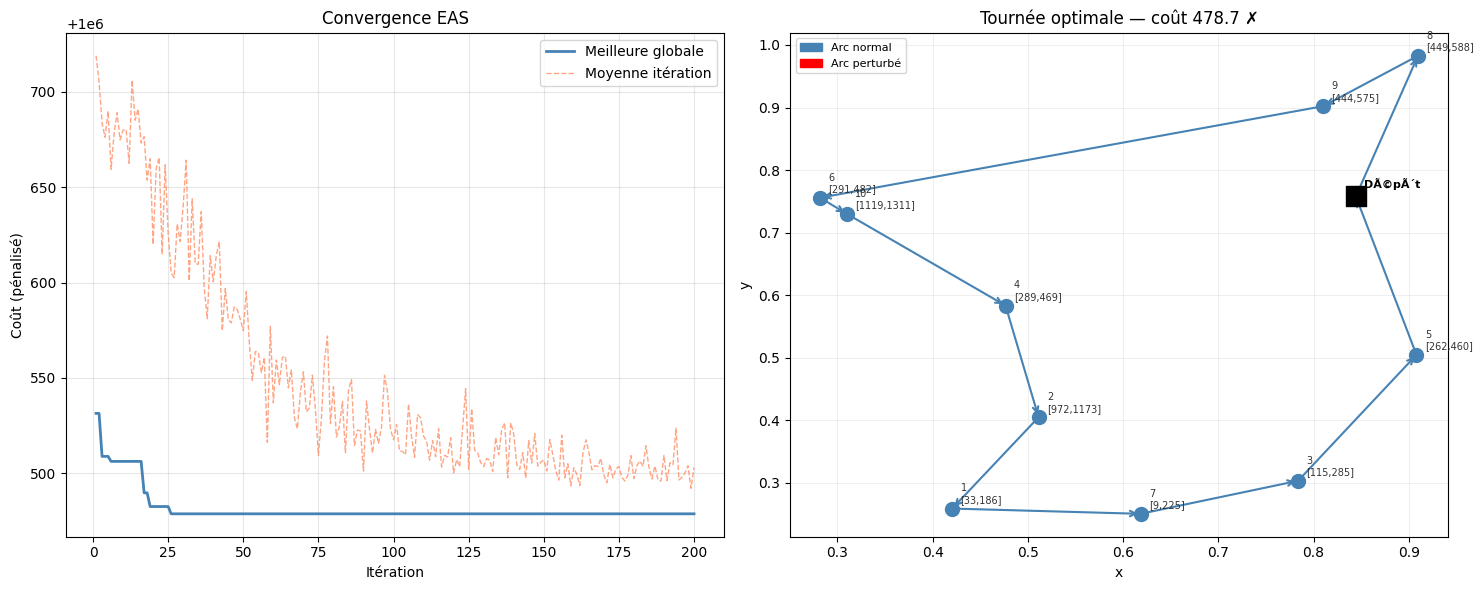

Figure sauvegardée : eas_result.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── 6a. Convergence ──────────────────────────────────────────────────────
ax = axes[0]
iters = range(1, len(result["history_best"]) + 1)
ax.plot(iters, result["history_best"], label="Meilleure globale", color="steelblue", lw=2)
ax.plot(iters, result["history_avg"],  label="Moyenne itération", color="coral",    lw=1, alpha=0.7, ls="--")
ax.set_xlabel("Itération")
ax.set_ylabel("Coût (pénalisé)")
ax.set_title("Convergence EAS")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 6b. Carte de la tournée ───────────────────────────────────────────────
ax = axes[1]
nodes = problem.nodes
route = [0] + result["route"] + [0]

# Arêtes perturbées (marquées en rouge)
perturbed_arcs = {(p.arc[0], p.arc[1]) for p in problem.perturbations}

for k in range(len(route) - 1):
    i, j = route[k], route[k + 1]
    xi, yi = nodes[i].x, nodes[i].y
    xj, yj = nodes[j].x, nodes[j].y
    color = "red" if (i, j) in perturbed_arcs or (j, i) in perturbed_arcs else "steelblue"
    ax.annotate("", xy=(xj, yj), xytext=(xi, yi),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

# Noeuds
depot = nodes[0]
ax.scatter(depot.x, depot.y, s=200, color="black", zorder=5, marker="s")
ax.annotate(depot.nom, (depot.x, depot.y), textcoords="offset points", xytext=(6, 6), fontsize=8, fontweight="bold")

for node in problem.clients:
    ax.scatter(node.x, node.y, s=100, color="steelblue", zorder=5)
    ax.annotate(f"{node.id}\n[{node.a:.0f},{node.b:.0f}]",
                (node.x, node.y), textcoords="offset points",
                xytext=(6, 4), fontsize=7, color="#333")

# Légende perturbations
if problem.perturbations:
    red_patch = mpatches.Patch(color="red",      label="Arc perturbé")
    blu_patch = mpatches.Patch(color="steelblue", label="Arc normal")
    ax.legend(handles=[blu_patch, red_patch], fontsize=8)

ax.set_title(f"Tournée optimale — coût {result['cost']:.1f} {'✓' if result['feasible'] else '✗'}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print("Figure sauvegardée : eas_result.png")

## 7. Expérimentation — sensibilité aux paramètres


=== Résultat final ===
  Coût réel  : 478.75
  Faisable   : False
  Route      : [0, 8, 9, 6, 10, 4, 2, 1, 7, 3, 5, 0]

=== Résultat final ===
  Coût réel  : 478.75
  Faisable   : False
  Route      : [0, 8, 9, 6, 10, 4, 2, 1, 7, 3, 5, 0]

=== Résultat final ===
  Coût réel  : 478.75
  Faisable   : False
  Route      : [0, 5, 3, 7, 1, 2, 4, 10, 6, 9, 8, 0]

=== Résultat final ===
  Coût réel  : 478.75
  Faisable   : False
  Route      : [0, 8, 9, 6, 10, 4, 2, 1, 7, 3, 5, 0]


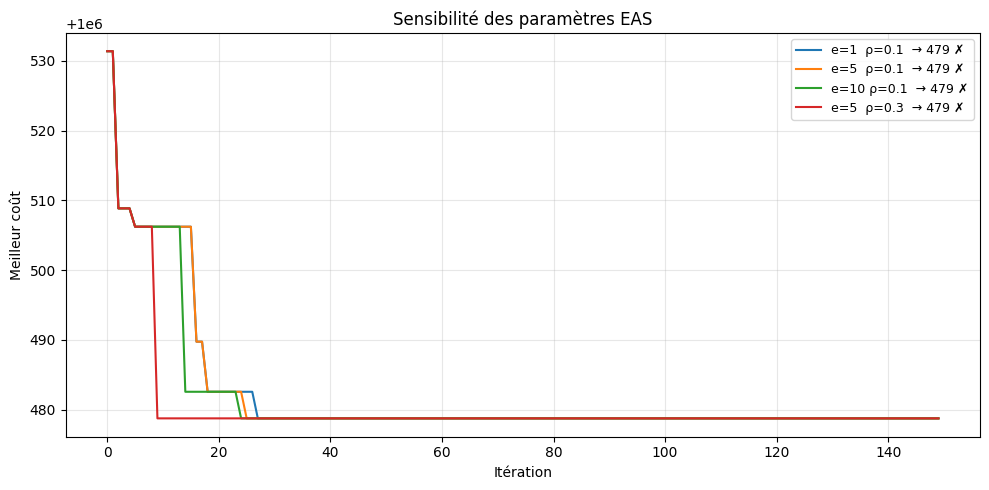

In [ ]:
param_grid = [
    {"e": 1,  "rho": 0.1, "label": "e=1  ρ=0.1"},
    {"e": 5,  "rho": 0.1, "label": "e=5  ρ=0.1"},
    {"e": 10, "rho": 0.1, "label": "e=10 ρ=0.1"},
    {"e": 5,  "rho": 0.3, "label": "e=5  ρ=0.3"},
]

plt.figure(figsize=(10, 5))

for params in param_grid:
    eas_exp = EAS(problem, n_ants=20, n_iter=150,
                  e=params["e"], rho=params["rho"], seed=42)
    res_exp = eas_exp.run(verbose=False)
    label = f"{params['label']}  → {res_exp['cost']:.0f} {'✓' if res_exp['feasible'] else '✗'}"
    plt.plot(res_exp["history_best"], label=label)

plt.xlabel("Itération")
plt.ylabel("Meilleur coût")
plt.title("Sensibilité des paramètres EAS")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Matrice de phéromones finale

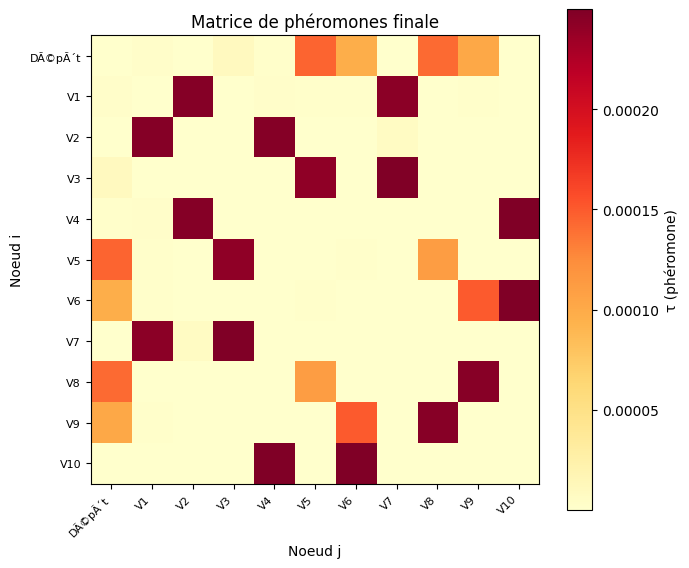

In [ ]:
plt.figure(figsize=(7, 6))
tau = eas.tau
plt.imshow(tau, cmap="YlOrRd")
plt.colorbar(label="τ (phéromone)")
plt.title("Matrice de phéromones finale")
plt.xlabel("Noeud j")
plt.ylabel("Noeud i")
labels = [n.nom.replace("Ville ", "V") for n in problem.nodes]
plt.xticks(range(problem.n), labels, rotation=45, ha="right", fontsize=8)
plt.yticks(range(problem.n), labels, fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# ── Cellule 1 : liste des fichiers à tester ──────────────────────────────
FICHIERS = [
    "datasets/tsptwd_n10.json",
    "datasets/tsptwd_n50.json",
    "datasets/tsptwd_n100.json",
    "datasets/tsptwd_n200.json",
    "datasets/tsptwd_n300.json",
]

In [10]:
# ── Cellule 2 : paramètres EAS communs ───────────────────────────────────
EAS_PARAMS = dict(
    n_ants  = 20,
    n_iter  = 200,
    alpha   = 1.0,
    beta    = 2.0,
    rho     = 0.1,
    e       = 5.0,
    penalty = 1e6,
)

In [11]:
# ── Cellule 3 : boucle principale ────────────────────────────────────────
import json, time
from pathlib import Path

resultats = {}   # stocke tout pour comparaison finale

for fichier in FICHIERS:
    path = Path(fichier)
    if not path.exists():
        print(f"⚠️  Fichier introuvable : {fichier}\n")
        continue

    print("=" * 60)
    print(f"📂  {fichier}")
    print("=" * 60)

    with open(path) as f:
        data = json.load(f)

    problem = TSPTW(data)
    print(f"    {problem.n_clients()} clients  |  "
          f"{len(problem.perturbations)} perturbation(s)  |  "
          f"horizon {problem.horizon}")

    eas = EAS(problem, seed=data["meta"].get("seed", 0), **EAS_PARAMS)

    t0  = time.perf_counter()
    res = eas.run(verbose=False)
    elapsed = time.perf_counter() - t0

    feas_str = "✓ faisable" if res["feasible"] else "✗ infaisable"
    print(f"    Coût    : {res['cost']:.2f}")
    print(f"    Statut  : {feas_str}")
    print(f"    Temps   : {elapsed:.2f}s")
    print(f"    Route   : {[0] + res['route'] + [0]}\n")

    resultats[fichier] = {
        "problem": problem,
        "eas":     eas,
        "result":  res,
        "elapsed": elapsed,
    }

📂  datasets/tsptwd_n10.json
    10 clients  |  2 perturbation(s)  |  horizon 1440.0

=== Résultat final ===
  Coût réel  : 478.75
  Faisable   : False
  Route      : [0, 8, 9, 6, 10, 4, 2, 1, 7, 3, 5, 0]
    Coût    : 478.75
    Statut  : ✗ infaisable
    Temps   : 0.22s
    Route   : [0, 8, 9, 6, 10, 4, 2, 1, 7, 3, 5, 0]

📂  datasets/tsptwd_n50.json
    50 clients  |  5 perturbation(s)  |  horizon 1440.0

=== Résultat final ===
  Coût réel  : 1340.94
  Faisable   : False
  Route      : [0, 50, 36, 10, 30, 16, 12, 21, 28, 13, 4, 17, 35, 38, 15, 32, 14, 2, 34, 49, 43, 27, 25, 44, 7, 33, 3, 22, 31, 24, 18, 40, 48, 5, 29, 1, 19, 6, 9, 45, 41, 11, 23, 37, 20, 26, 47, 46, 42, 39, 8, 0]
    Coût    : 1340.94
    Statut  : ✗ infaisable
    Temps   : 3.15s
    Route   : [0, 50, 36, 10, 30, 16, 12, 21, 28, 13, 4, 17, 35, 38, 15, 32, 14, 2, 34, 49, 43, 27, 25, 44, 7, 33, 3, 22, 31, 24, 18, 40, 48, 5, 29, 1, 19, 6, 9, 45, 41, 11, 23, 37, 20, 26, 47, 46, 42, 39, 8, 0]

📂  datasets/tsptwd_n100.json

In [12]:
# ── Cellule 4 : tableau récapitulatif ────────────────────────────────────
print(f"\n{'Fichier':<30} {'Clients':>7} {'Coût':>10} {'Faisable':>9} {'Temps':>7}")
print("-" * 67)
for fichier, r in resultats.items():
    nom     = Path(fichier).stem
    n       = r["problem"].n_clients()
    cost    = r["result"]["cost"]
    feas    = "✓" if r["result"]["feasible"] else "✗"
    elapsed = r["elapsed"]
    print(f"{nom:<30} {n:>7} {cost:>10.2f} {feas:>9} {elapsed:>6.2f}s")


Fichier                        Clients       Coût  Faisable   Temps
-------------------------------------------------------------------
tsptwd_n10                          10     478.75         ✗   0.22s
tsptwd_n50                          50    1340.94         ✗   3.15s
tsptwd_n100                        100    1762.43         ✗  11.57s
tsptwd_n200                        200    2522.22         ✗  44.14s
tsptwd_n300                        300    3086.64         ✗  97.69s


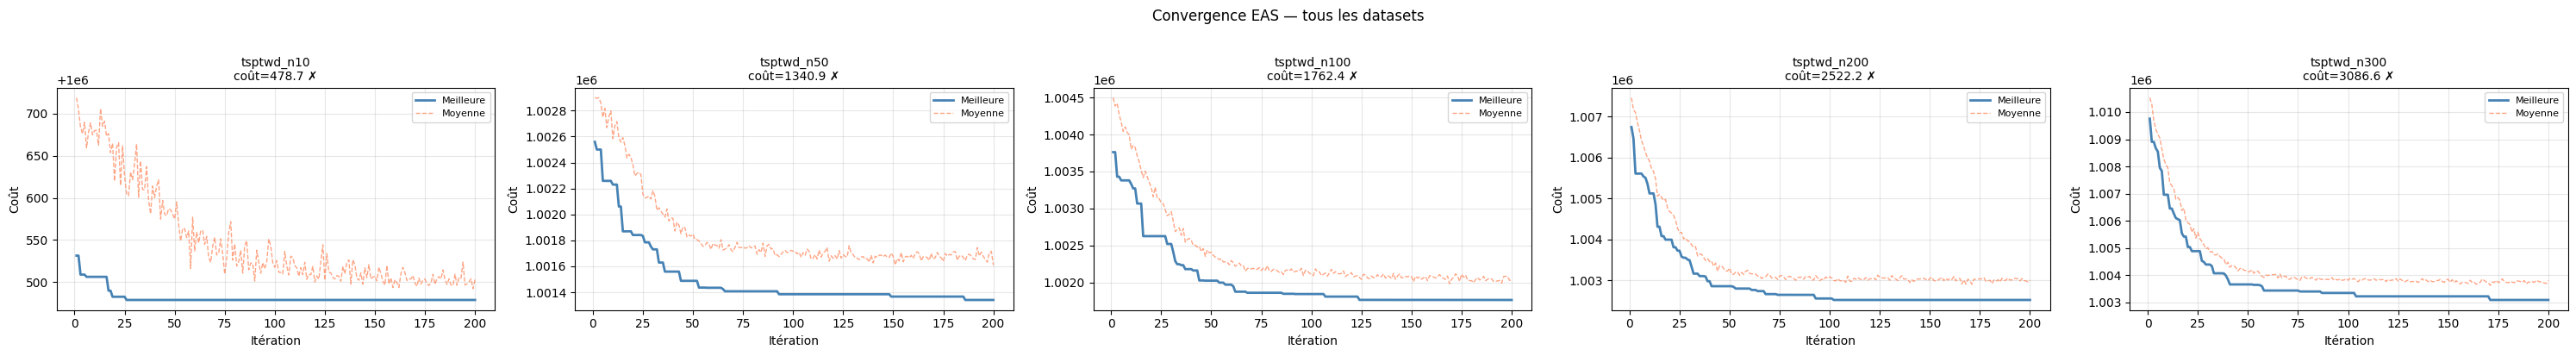

In [13]:
# ── Cellule 5 : courbes de convergence superposées ───────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(resultats), figsize=(6 * len(resultats), 4),
                         squeeze=False)

for ax, (fichier, r) in zip(axes[0], resultats.items()):
    hist_best = r["result"]["history_best"]
    hist_avg  = r["result"]["history_avg"]
    iters = range(1, len(hist_best) + 1)

    ax.plot(iters, hist_best, label="Meilleure", color="steelblue", lw=2)
    ax.plot(iters, hist_avg,  label="Moyenne",   color="coral", lw=1,
            ls="--", alpha=0.7)

    feas = "✓" if r["result"]["feasible"] else "✗"
    ax.set_title(f"{Path(fichier).stem}\ncoût={r['result']['cost']:.1f} {feas}",
                 fontsize=10)
    ax.set_xlabel("Itération")
    ax.set_ylabel("Coût")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Convergence EAS — tous les datasets", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

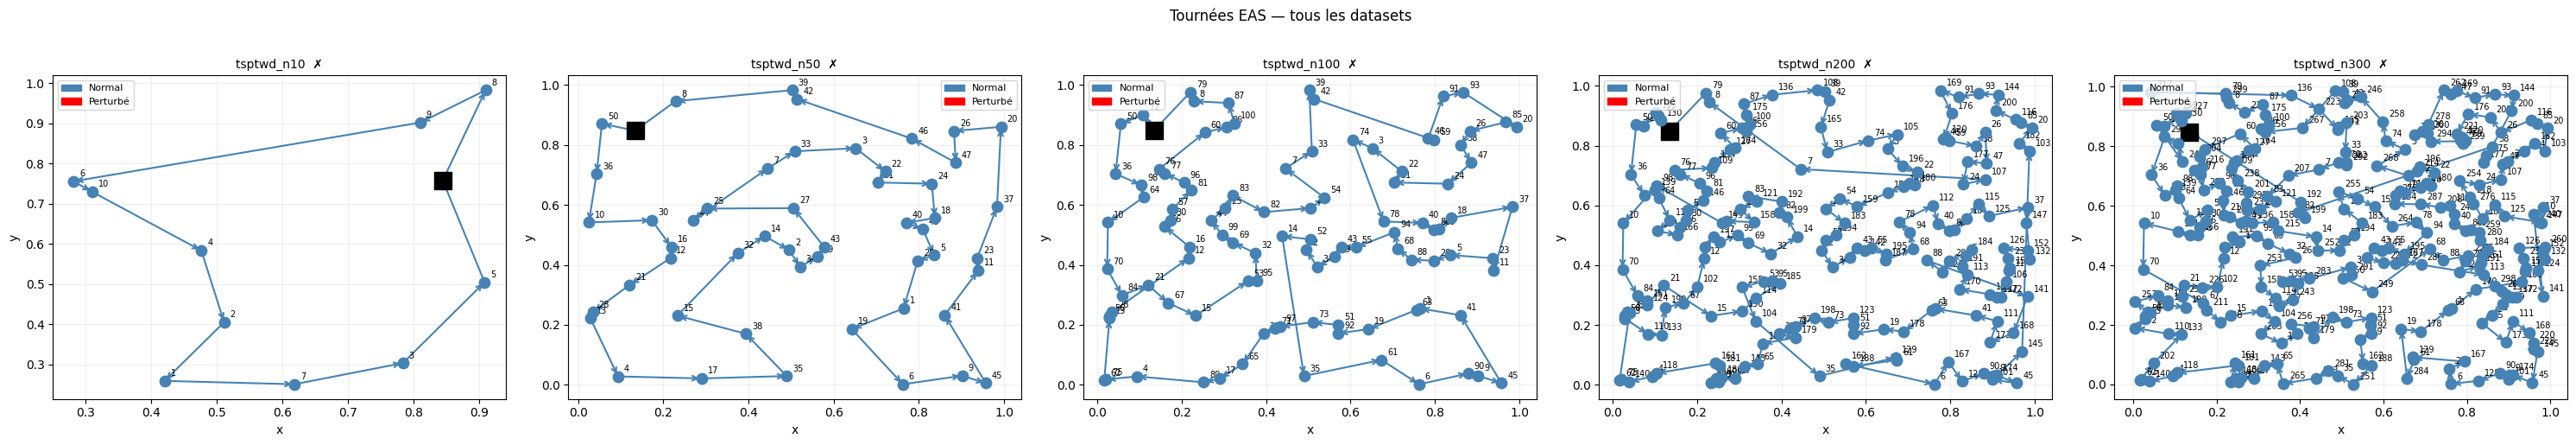

In [14]:
# ── Cellule 6 : cartes des tournées ──────────────────────────────────────
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(resultats), figsize=(6 * len(resultats), 5),
                         squeeze=False)

for ax, (fichier, r) in zip(axes[0], resultats.items()):
    problem = r["problem"]
    route   = [0] + r["result"]["route"] + [0]
    nodes   = problem.nodes
    perturbed = {(p.arc[0], p.arc[1]) for p in problem.perturbations}

    for k in range(len(route) - 1):
        i, j = route[k], route[k + 1]
        color = "red" if (i,j) in perturbed or (j,i) in perturbed else "steelblue"
        ax.annotate("", xy=(nodes[j].x, nodes[j].y),
                        xytext=(nodes[i].x, nodes[i].y),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

    depot = nodes[0]
    ax.scatter(depot.x, depot.y, s=200, color="black", zorder=5, marker="s")
    for node in problem.clients:
        ax.scatter(node.x, node.y, s=80, color="steelblue", zorder=5)
        ax.annotate(str(node.id), (node.x, node.y),
                    textcoords="offset points", xytext=(5, 4), fontsize=7)

    feas = "✓" if r["result"]["feasible"] else "✗"
    ax.set_title(f"{Path(fichier).stem}  {feas}", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(True, alpha=0.2)

    if problem.perturbations:
        ax.legend(handles=[
            mpatches.Patch(color="steelblue", label="Normal"),
            mpatches.Patch(color="red",       label="Perturbé"),
        ], fontsize=8)

plt.suptitle("Tournées EAS — tous les datasets", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()